# 🏷️ Conditional Generative Adversarial Networks (cGANs)

In the previous notebook, we built a standard GAN/DCGAN. While the models generated realistic-looking images, we had a fundamental problem: **we couldn't control the output.** The Generator randomly decided whether to produce a '0', '5', or '9'.

### The Problem of Control
Unconditional GANs model the joint distribution $P(\mathbf{x})$ (the probability of an image $\mathbf{x}$).

### The cGAN Solution: Introducing Condition
A **Conditional GAN (cGAN)** models the conditional distribution $P(\mathbf{x} | c)$, where $c$ is the **condition**. By providing the condition $c$ (e.g., a class label, a description, or another image), we guide the generation process.

The conditioning information $c$ is integrated into **both** the Generator ($G$) and the Discriminator ($D$).

### Key Applications of cGANs
1.  **Image Generation by Class:** Generate a specific object (e.g., a cat) from noise. (Our practical example)
2.  **Image-to-Image Translation:** Generate a map from a satellite image (Pix2Pix).
3.  **Text-to-Image Synthesis:** Generate an image from a text description (e.g., a "red flower with green leaves").

## 1. Architecture: How Conditioning Works

The core structure of the adversarial game remains the same, but the input vectors change.

![cGAN architecture](https://miro.medium.com/v2/resize:fit:1400/1*yO9fLGCR9mOgTVWUKiYQSQ.png)

### 1. The Conditional Generator ($G$)
The Generator is trained to map the latent noise $\mathbf{z}$ and the condition $c$ to a realistic image $\mathbf{x'}$.

* **Input:** The noise vector $\mathbf{z}$ is **concatenated** with the one-hot encoded condition vector $c$.

$$\mathbf{x'} = G(\mathbf{z}, c)$$

### 2. The Conditional Discriminator ($D$)
The Discriminator must determine two things:
1.  Is the image $\mathbf{x}$ real or fake?
2.  Does the image $\mathbf{x}$ match the provided condition $c$?

* **Input:** The image (real $\mathbf{x}$ or fake $\mathbf{x'}$) is **concatenated** with the one-hot encoded condition vector $c$.

$$\text{Score} = D(\mathbf{x}, c)$$

### 3. The Objective Function
The cGAN objective is a direct extension of the standard GAN minimax game, with both $G$ and $D$ conditioned on $c$:

$$\min_G \max_D \mathbb{E}_{\mathbf{x}, c} [\log D(\mathbf{x}|c)] + \mathbb{E}_{\mathbf{z}, c} [\log (1 - D(G(\mathbf{z}|c)))]$$

## 2. Setup and Data Preparation

For our practical example, we will implement a simple MLP-based cGAN on MNIST, allowing us to generate any digit from 0 to 9 by specifying the label.

### Data Preparation: One-Hot Encoding
Since the condition $c$ is the digit label (0 to 9), we must convert it into a **one-hot vector** (a 10-dimensional vector with a '1' in the position of the class, and '0' elsewhere).

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration
IMAGE_SIZE = 28 * 28 # MNIST image size
Z_DIM = 100          # Latent noise dimension
C_DIM = 10           # Condition dimension (10 classes: 0-9)
INPUT_DIM_G = Z_DIM + C_DIM # 110
INPUT_DIM_D = IMAGE_SIZE + C_DIM # 784 + 10 = 794

# Training parameters
LEARNING_RATE = 2e-4
BATCH_SIZE = 128
NUM_EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Data Loading and Preprocessing ---

# Transforms: ToTensor and Normalize for pixel values [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1] range for better GAN stability
])

# Load MNIST data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Using device: cuda


In [4]:
# --- 3. Conditional Generator (MLP) ---
class Generator(nn.Module):
    def __init__(self, input_dim, img_dim):
        super().__init__()
        self.main = nn.Sequential(
            # Input size: Z_DIM (100) + C_DIM (10) = 110
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim), # Output size: 784
            nn.Tanh() # Output range [-1, 1] to match normalized input data
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28) # Reshape to 1x28x28 image

# --- 4. Conditional Discriminator (MLP) ---
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.main = nn.Sequential(
            # Input size: Image (784) + C_DIM (10) = 794
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1), # Output size: 1 (Real/Fake score)
            nn.Sigmoid() # Output activation for BCE Loss
        )

    def forward(self, x):
        return self.main(x)

In [6]:
# --- 5. Training Setup ---

G = Generator(INPUT_DIM_G, IMAGE_SIZE).to(device)
D = Discriminator(INPUT_DIM_D).to(device)

optimizer_D = optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_G = optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.BCELoss() # Binary Cross-Entropy Loss

# --- Helper Function: One-Hot Encoding ---
def one_hot_encode(labels, num_classes=C_DIM):
    """Converts a tensor of labels (integers) into a one-hot vector."""
    # Ensure the identity matrix is on the same device as the labels
    return torch.eye(num_classes, device=labels.device)[labels]

# --- 6. Training Loop ---

print("Starting cGAN Training...")

for epoch in range(NUM_EPOCHS):
    for i, (real_imgs, labels) in enumerate(train_loader):

        N = real_imgs.size(0)

        # --- Data Preparation ---
        real_imgs = real_imgs.view(N, -1).to(device) # Flatten real image (1, 784)

        # One-hot encode the true labels
        c_real = one_hot_encode(labels.to(device)) # N x 10, ensure labels are on device before encoding

        # Concatenate image and condition for D input
        D_input_real = torch.cat([real_imgs, c_real], dim=1) # N x 794

        # Create target labels (1 for real, 0 for fake)
        real_labels = torch.ones(N, 1).to(device)
        fake_labels = torch.zeros(N, 1).to(device)

        # ====================================================================
        # (1) Update Discriminator: Maximize log(D) + log(1 - D(G))
        # ====================================================================

        # 1A. Train D on Real Data
        D_output_real = D(D_input_real)
        D_loss_real = criterion(D_output_real, real_labels)

        # 1B. Train D on Fake Data

        # Generate random noise and random condition for G input
        z = torch.randn(N, Z_DIM).to(device) # N x 100
        # Sample random labels for the fake generation
        random_labels = torch.randint(0, C_DIM, (N,)).to(device)
        c_fake = one_hot_encode(random_labels) # N x 10

        # Concatenate noise and condition for G input
        G_input = torch.cat([z, c_fake], dim=1) # N x 110

        fake_imgs = G(G_input).view(N, -1) # Generate fake image, flatten (N x 784)

        # Concatenate fake image and condition for D input
        D_input_fake = torch.cat([fake_imgs.detach(), c_fake], dim=1) # Use .detach() to stop gradient flow to G
        D_output_fake = D(D_input_fake)
        D_loss_fake = criterion(D_output_fake, fake_labels)

        # Total D Loss
        D_loss = D_loss_real + D_loss_fake

        D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        # ====================================================================
        # (2) Update Generator: Maximize log(D(G))
        # ====================================================================

        # Generate new random noise and condition for G
        z = torch.randn(N, Z_DIM).to(device)
        random_labels = torch.randint(0, C_DIM, (N,)).to(device)
        c_gen = one_hot_encode(random_labels) # N x 10

        G_input = torch.cat([z, c_gen], dim=1)
        fake_imgs = G(G_input).view(N, -1)

        # Concatenate fake image and condition for D input
        D_input_gen = torch.cat([fake_imgs, c_gen], dim=1)
        D_output_gen = D(D_input_gen)

        # G's objective is to fool D (make D think fake images are real)
        G_loss = criterion(D_output_gen, real_labels) # Use REAL_labels as the target

        G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

    # --- Print Progress ---
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Loss D: {D_loss.item():.4f}, Loss G: {G_loss.item():.4f}')

print("Training complete.")

Starting cGAN Training...
Epoch [1/50] Loss D: 0.1586, Loss G: 5.0116
Epoch [2/50] Loss D: 0.2625, Loss G: 3.1369
Epoch [3/50] Loss D: 0.2908, Loss G: 3.8314
Epoch [4/50] Loss D: 0.2529, Loss G: 3.7770
Epoch [5/50] Loss D: 0.3232, Loss G: 3.1957
Epoch [6/50] Loss D: 0.3624, Loss G: 5.3343
Epoch [7/50] Loss D: 2.5501, Loss G: 2.0066
Epoch [8/50] Loss D: 0.4343, Loss G: 2.5631
Epoch [9/50] Loss D: 0.8989, Loss G: 3.1497
Epoch [10/50] Loss D: 0.5501, Loss G: 2.2261
Epoch [11/50] Loss D: 0.8563, Loss G: 1.5678
Epoch [12/50] Loss D: 0.8021, Loss G: 1.4423
Epoch [13/50] Loss D: 0.9965, Loss G: 1.2241
Epoch [14/50] Loss D: 1.0675, Loss G: 1.5863
Epoch [15/50] Loss D: 1.1582, Loss G: 1.3231
Epoch [16/50] Loss D: 1.0495, Loss G: 1.0521
Epoch [17/50] Loss D: 1.1032, Loss G: 1.1571
Epoch [18/50] Loss D: 1.1153, Loss G: 1.1211
Epoch [19/50] Loss D: 1.1259, Loss G: 0.9985
Epoch [20/50] Loss D: 1.1959, Loss G: 1.1981
Epoch [21/50] Loss D: 1.0345, Loss G: 1.1098
Epoch [22/50] Loss D: 1.2434, Loss G: 

## 7. Evaluation: Controlled Generation

The true test of a cGAN is its ability to generate images *conditioned* on a specific label. We will now manually set the condition vector $c$ to generate each digit from 0 to 9.

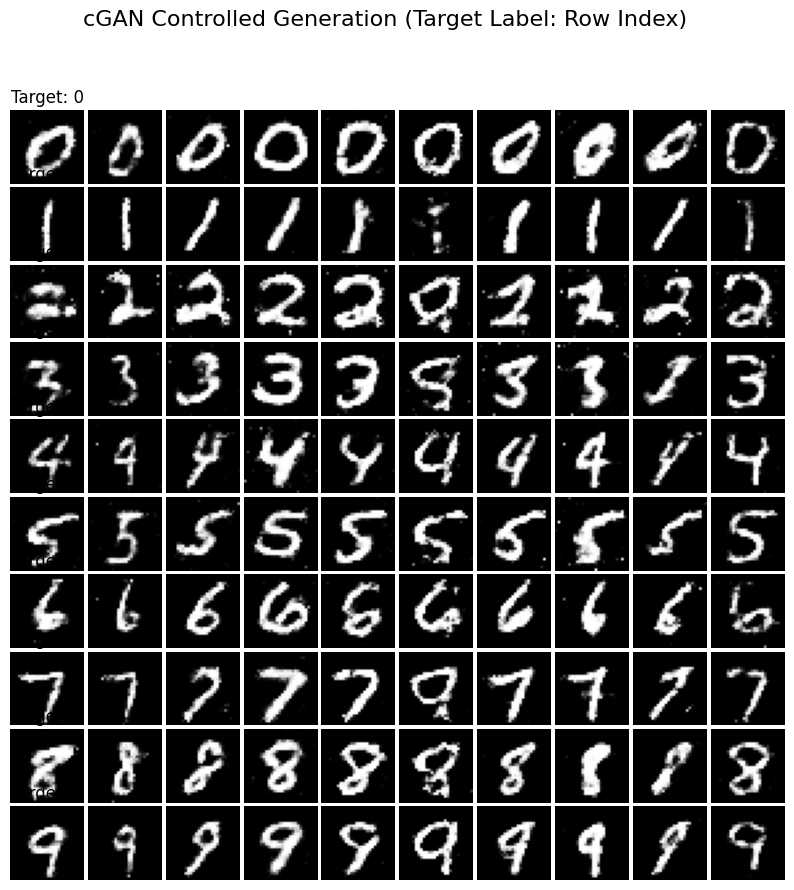

In [7]:
# --- 1. Setup for Generation ---
G.eval()
N_ROWS = 10
N_COLS = 10

# Create a fixed set of noise vectors for consistent comparison
fixed_noise = torch.randn(N_COLS, Z_DIM).to(device)

# --- 2. Generation Loop ---
generated_images = []

for target_digit in range(N_ROWS): # Iterate through digits 0 to 9

    # Create the condition vector for the current digit (N_COLS repetitions of the target_digit)
    labels = torch.full((N_COLS,), target_digit, dtype=torch.long).to(device)
    c_fixed = one_hot_encode(labels) # N_COLS x 10

    # Concatenate fixed noise and condition
    G_input_fixed = torch.cat([fixed_noise, c_fixed], dim=1)

    # Generate images
    with torch.no_grad():
        img_batch = G(G_input_fixed).cpu().detach()
        generated_images.append(img_batch)

# Concatenate all generated batches into a single tensor
final_output = torch.cat(generated_images, dim=0)

# --- 3. Visualization ---
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(10, 10))

for r in range(N_ROWS):
    for c in range(N_COLS):
        img = final_output[r * N_COLS + c].squeeze()

        # Un-normalize the image from [-1, 1] back to [0, 1]
        img = (img + 1) / 2

        axes[r, c].imshow(img, cmap='gray')
        axes[r, c].axis('off')

        if c == 0:
            axes[r, c].set_title(f'Target: {r}', fontsize=12, loc='right', pad=5)

plt.suptitle("cGAN Controlled Generation (Target Label: Row Index)", fontsize=16)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

## 8. Conclusion and Next Steps

We successfully extended the standard GAN framework into a **Conditional GAN (cGAN)** by incorporating class labels into both the Generator's input and the Discriminator's input.

The resulting model demonstrates true **controllability**: by manipulating the one-hot condition vector, we can reliably generate a specific digit of our choosing. This is a crucial step towards more sophisticated generative tasks, such as generating complex images from text or performing domain translation.

In the next notebook, we will move to the cutting edge of generative models: **Diffusion Models**, which offer unprecedented stability, diversity, and realism compared to the GAN framework.